# Diversity sustained by new clones

In [1]:
import numpy as np
import pyrepseq as prs
from scipy.signal import welch
from scipy.stats import weibull_min

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import repertoire_simulator.lib as lib

plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

/Users/james/Documents/Projects/repertoire_sims_2026/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Analysis for $\alpha = 1.2$

In [2]:
ratios = np.logspace(1, 5.5, 10)
results_for_ratio = {}
cs_final_for_ratio = {}
cmaxes_for_ratio = {}
for ratio in ratios:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/alpha_1.2/ratio_{ratio}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff = np.zeros(len(t))
    T = np.zeros(len(t))
    S = np.zeros(len(t))
    cmax = np.zeros(len(t))
    
    cs_final_for_ratio[ratio] = c_t[-1]
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        T[i] = np.mean(c_t[i].sum(axis=0))
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        cmax[i] = np.max(c_t[i])
        
    results_for_ratio[ratio] = {'t':t, 'Seff':Seff, 'T':T, 'S':S, 'cmax':cmax}

### Clone size distribution

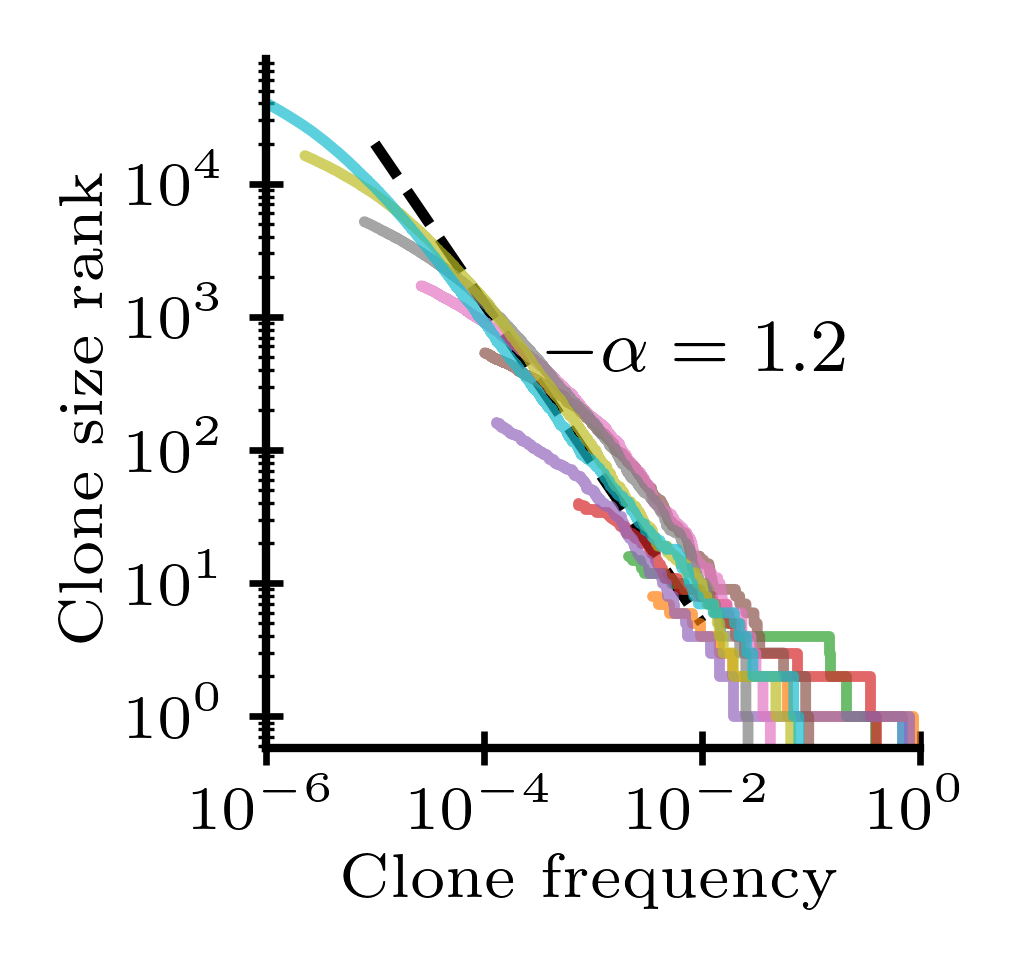

In [3]:
fig, ax = plt.subplots(figsize=(1.6, 1.5), layout='constrained')
lib.plot_referencescaling(ax=ax, x=[1e-5, 1e-2], factor=2e-2, exponent=-1.2, linestyle='--')
for ratio in ratios:
    c = cs_final_for_ratio[ratio]
    prs.plotting.rankfrequency(c[c >= 1], ax=ax, normalize_x=True, alpha=0.7)
ax.set_xlim([1e-6, 1e0]);

### Scaling of $S_{\mathrm{eff}}$

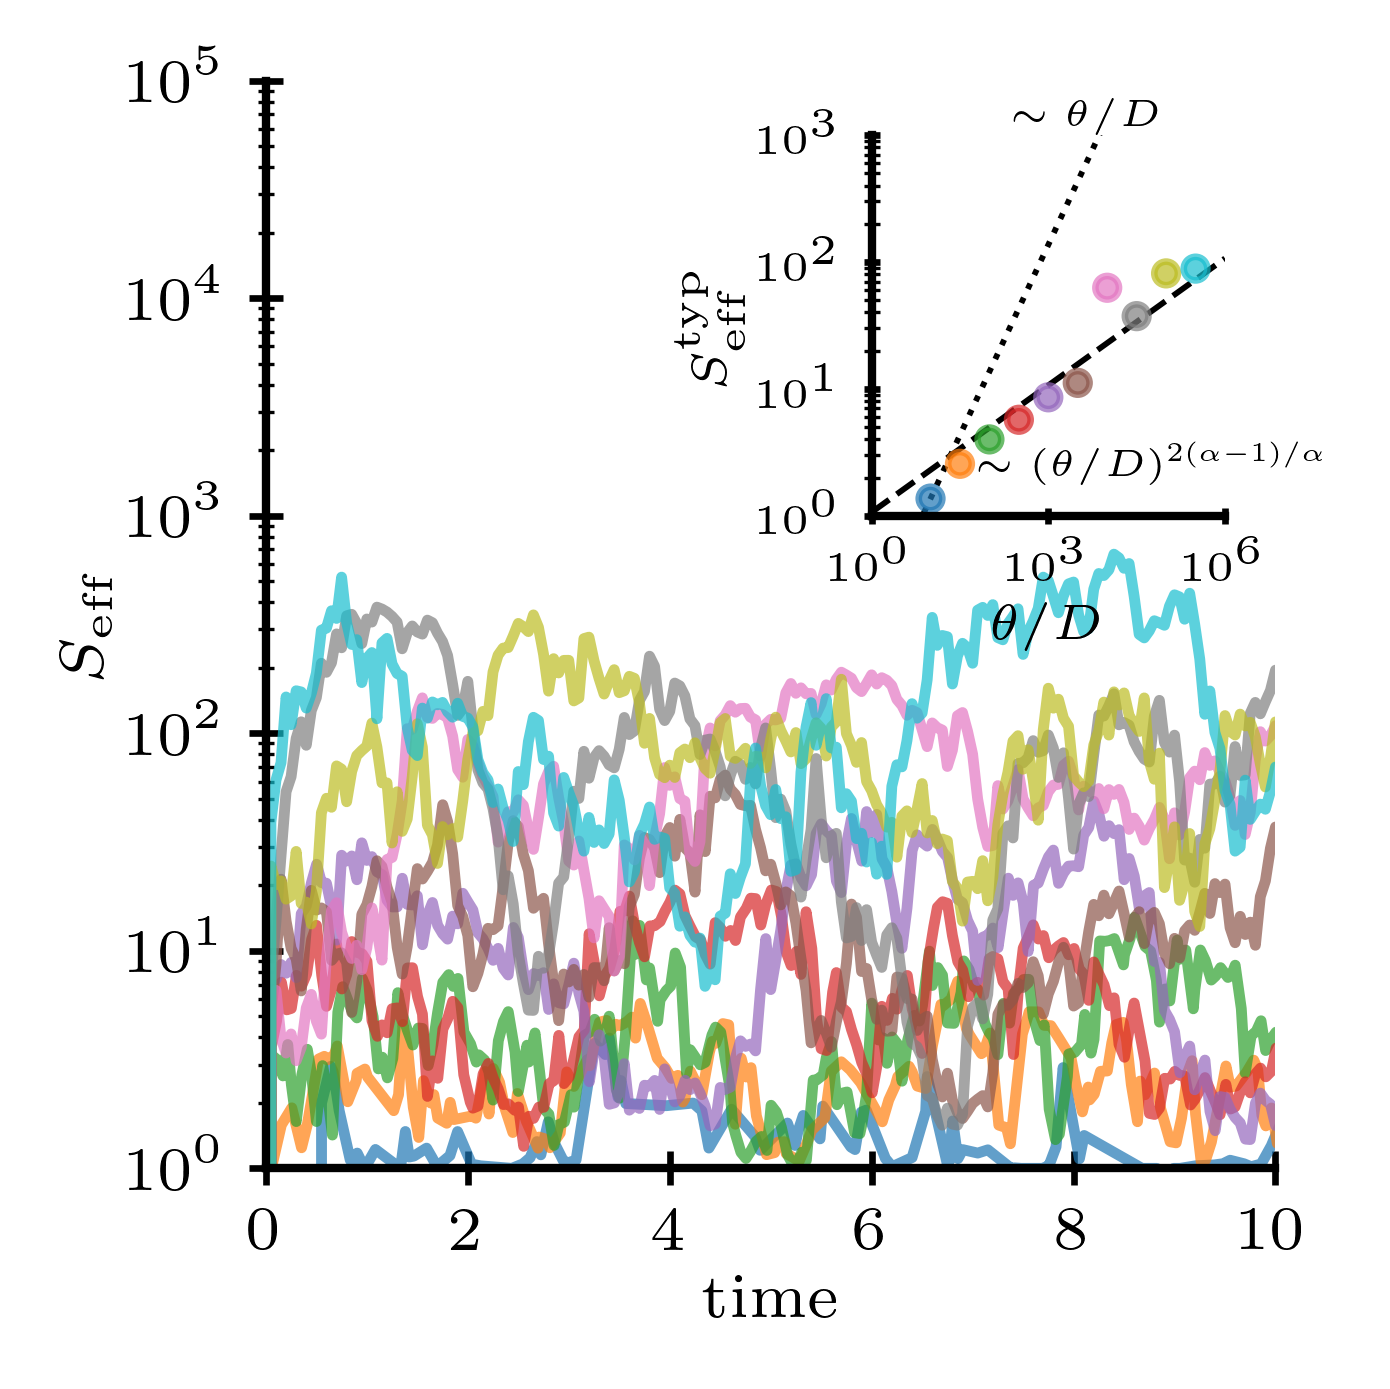

In [4]:
fig, ax = plt.subplots(figsize=(2.2, 2.2), layout='constrained')

alpha = 1.2
typical_diversities = []
colors = []
for ratio in ratios:
    t =  results_for_ratio[ratio]['t']
    
    Seff =  results_for_ratio[ratio]['Seff']
    line, = ax.plot(t, Seff, alpha=0.7)
    colors.append(line.get_color())    
    
    typical_Seff = lib.geometric_mean_after_burn(Seff)
    typical_diversities.append(typical_Seff)

ax.set_yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1, 1e5)
ax.set_xlabel(r'time')
ax.set_ylabel(r'$S_{\mathrm{eff}}$')

inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
inset.scatter(ratios, typical_diversities, s=8, c=np.asarray(colors), alpha=0.7)
inset.set_xscale('log')
inset.set_yscale('log')

ratio_range = np.logspace(0, 6, 100)
prefactor = lib.fit_power_law_prefactor(ratios, typical_diversities, (2 * (alpha - 1) / alpha))
inset.plot(ratio_range, prefactor * ratio_range ** (2 * (alpha - 1) / alpha), linestyle='--', c='black', lw=0.7, zorder=-2) 
inset.plot(ratio_range, (typical_diversities[0] / ratios[0]) * ratio_range , linestyle=':', c='black', lw=0.7, zorder=-2)

inset.text(0.4, 1.1, r'$\sim \theta/D$', transform=inset.transAxes, fontsize=4.5, ha='left',va='top')
inset.text(0.3, 0.2, r'$\sim(\theta/D)^{2(\alpha-1)/\alpha}$', transform=inset.transAxes, fontsize=4.5, ha='left',va='top')
inset.set_ylim([1, 1e3])
inset.set_xlim([1, 1e6])

inset.set_xlabel(r'$\theta / D$', fontsize=6)
inset.set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{typ}}$', fontsize=6)
inset.tick_params(axis='both', labelsize=5, length=2)
plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_diversity_with_recruitment_alpha_1.2.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Scaling of Richness

/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_69024/715966079.py:9: RuntimeWarning: divide by zero encountered in log
  ax[2].plot(results_for_ratio[ratio]['t'], np.log(results_for_ratio[ratio]['Seff'])/np.log(results_for_ratio[ratio]['S']), alpha=0.7)
/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_69024/715966079.py:9: RuntimeWarning: invalid value encountered in divide
  ax[2].plot(results_for_ratio[ratio]['t'], np.log(results_for_ratio[ratio]['Seff'])/np.log(results_for_ratio[ratio]['S']), alpha=0.7)


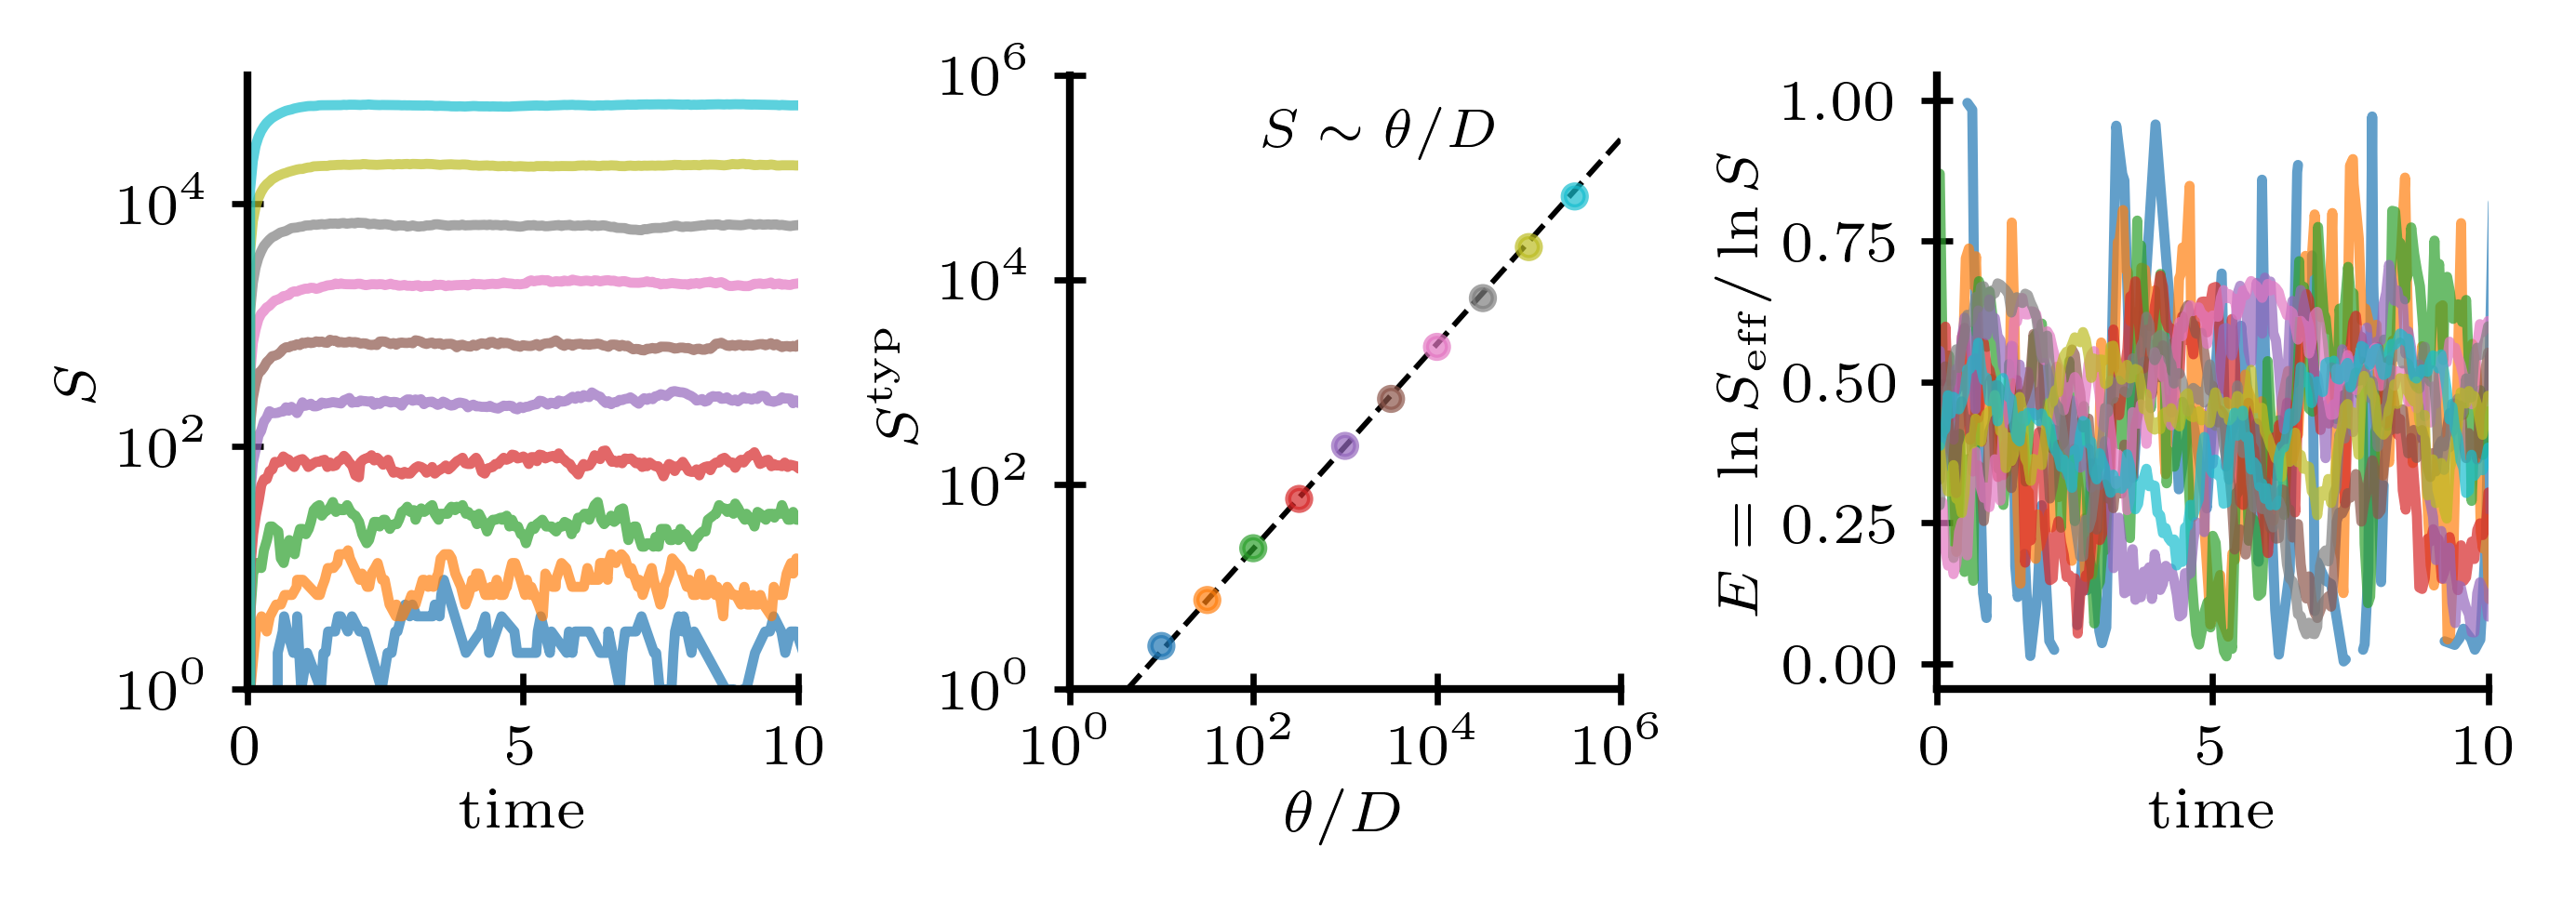

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(4.5, 1.5), layout='constrained')
D = 1
gamma = 0.2
alpha = 1.2
typical_richness = []
T_stars = []
for ratio in ratios:    
    ax[0].plot(results_for_ratio[ratio]['t'], results_for_ratio[ratio]['S'], alpha=0.7)
    ax[2].plot(results_for_ratio[ratio]['t'], np.log(results_for_ratio[ratio]['Seff'])/np.log(results_for_ratio[ratio]['S']), alpha=0.7)
    
    S =  results_for_ratio[ratio]['S']
    typical_richness.append(lib.geometric_mean_after_burn(S))
        
ax[0].set_xlim(0, 10)
ax[0].set_yscale('log')
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$S$')
ax[0].set_ylim(1, None)

ratio_range = np.logspace(0, 6, 100)
ax[1].plot(ratio_range, (typical_richness[1] / ratios[1])*ratio_range , linestyle='--', c='black', lw=0.7, zorder=-2)
ax[1].text(0.35, 0.95, r'$S \sim \theta / D$', transform=ax[1].transAxes, fontsize=7, ha='left',va='top');
ax[1].set_xlabel(r'$\theta / D$')
ax[1].set_ylabel(r'$S^{\mathrm{typ}}$')
ax[1].scatter(ratios, typical_richness, s=8, c=np.asarray(colors), alpha=0.7)
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim([1, 1e6])
ax[1].set_ylim([1, 1e6])

ax[2].set_xlabel(r'time')
ax[2].set_ylabel(r'$E = \ln S_{\mathrm{eff}}/ \ln S$')
ax[2].set_xlim(0, 10);

### Total repertoire size and the largest clone

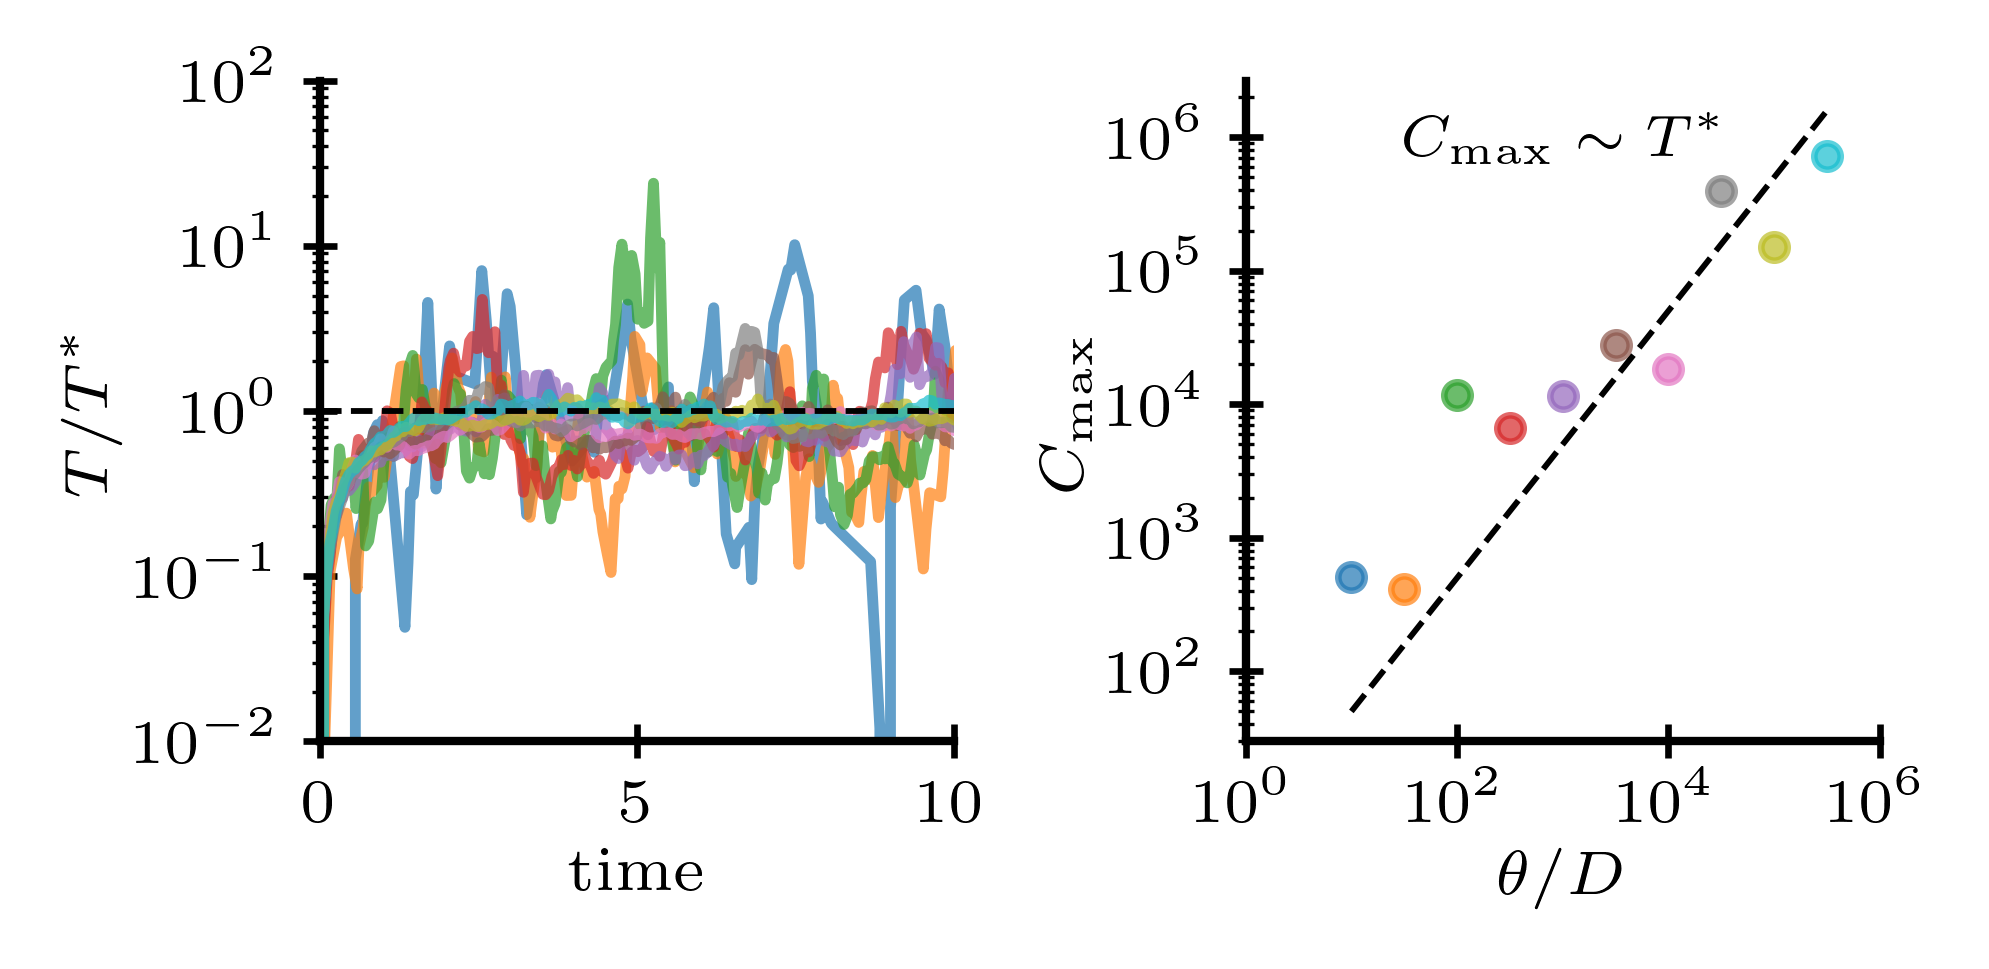

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(3.2, 1.5), layout='constrained')
D = 1
gamma = 0.2
alpha = 1.2
T_stars = []
for ratio in ratios:
    T_star = ratio / (alpha - 1)  
    line,  = ax[0].plot(results_for_ratio[ratio]['t'], results_for_ratio[ratio]['T'] / T_star, alpha=0.7)
    ax[1].scatter(ratio, np.max(results_for_ratio[ratio]['cmax']), s=10, alpha=0.7) 
    T_stars.append(T_star)
    
ax[0].axhline(1, c='black', linestyle='--', lw=0.7)
ax[0].set_yscale('log')
ax[0].set_xlim(0, 10)
ax[0].set_ylim(1e-2, 1e2)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$T / T^*$')
 
ax[1].plot(ratios, T_stars , linestyle='--', c='black', zorder=-2, lw=0.7)
ax[1].set_xlabel(r'$\theta / D$')
ax[1].set_ylabel(r'$C_{\max}$')
ax[1].text(0.25, 0.95, r'$C_{\mathrm{max}} \sim T^{*}$', transform=ax[1].transAxes, fontsize=7, ha='left',va='top')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1, 1e6]);

### Fluctuations in diversity

/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_69024/2225591845.py:9: RuntimeWarning: divide by zero encountered in log
  logSeff =  np.log(results_for_ratio[ratio]['Seff'][burn:])
/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_69024/2225591845.py:10: RuntimeWarning: invalid value encountered in subtract
  delta_logSeff = logSeff - np.mean(logSeff)


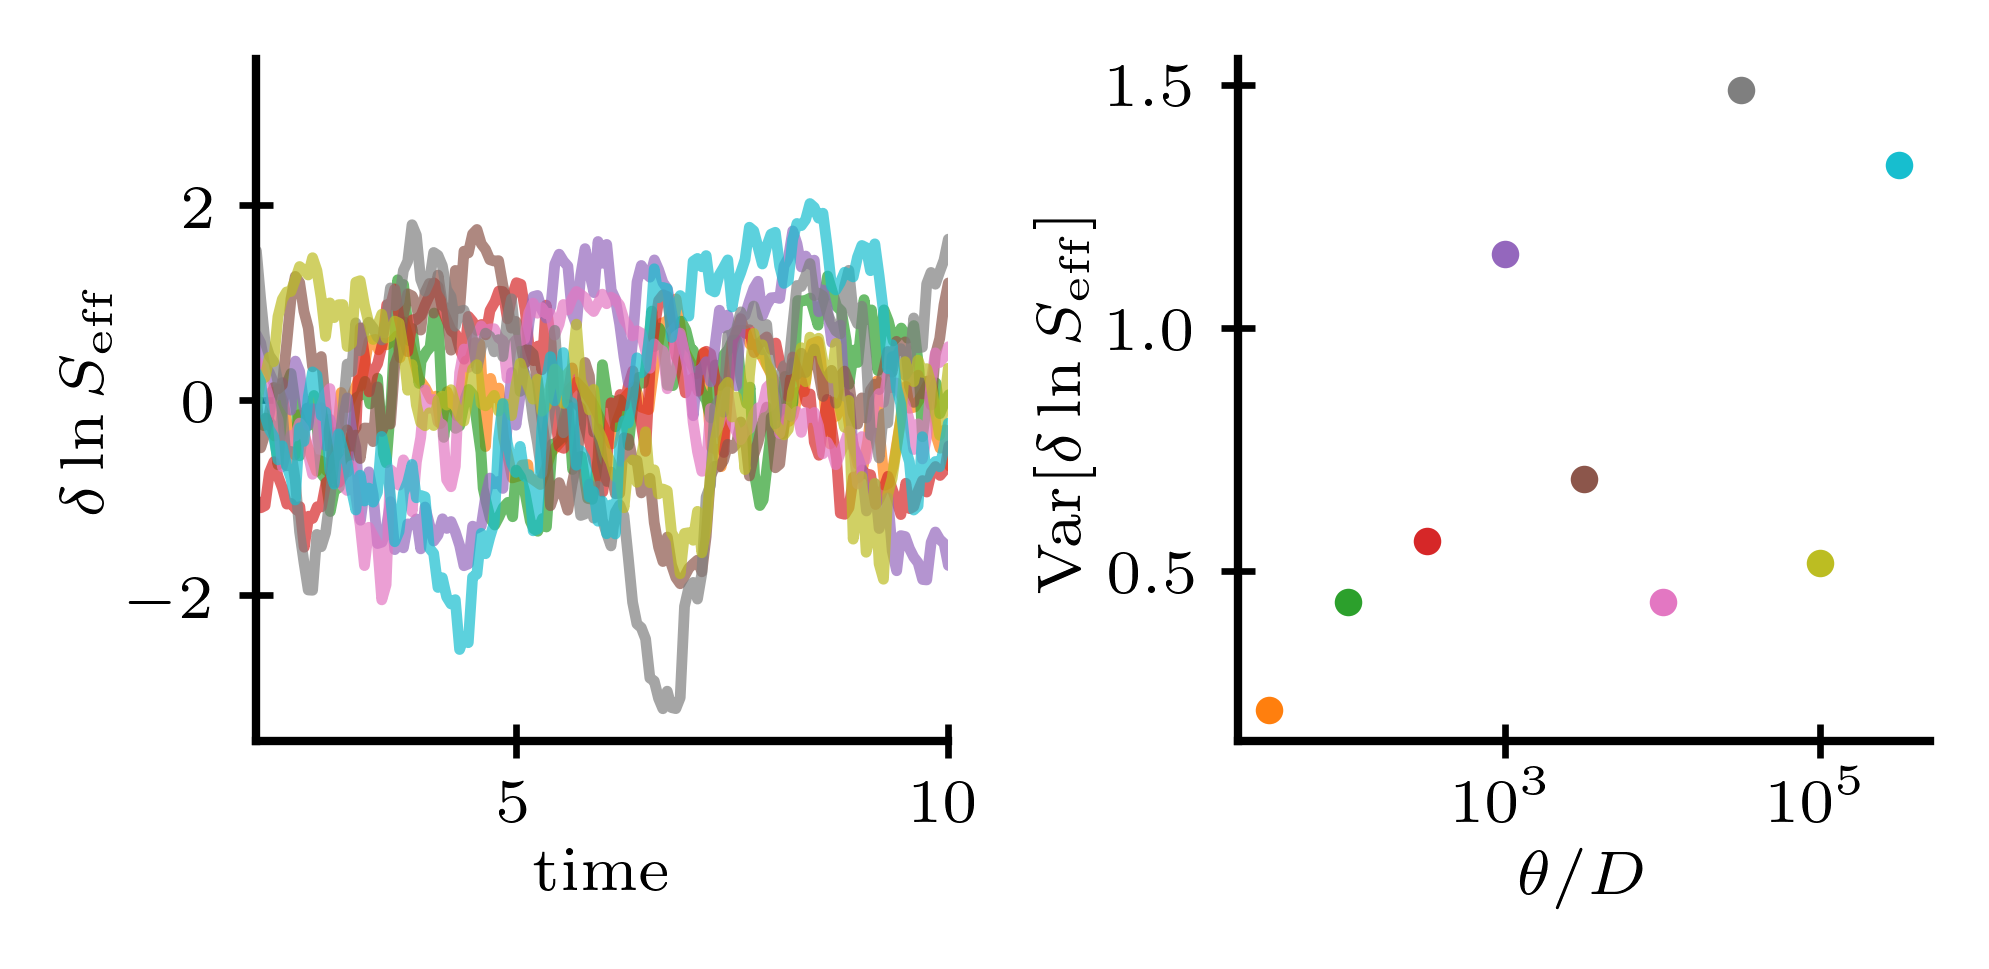

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(3.2, 1.5), layout='constrained')

alpha = 1.2
for ratio in ratios:
    
    t =  results_for_ratio[ratio]['t']
    burn = int(len(t) * 0.2)
    t = t[burn:]
    logSeff =  np.log(results_for_ratio[ratio]['Seff'][burn:])
    delta_logSeff = logSeff - np.mean(logSeff)

    ax[0].plot(t, delta_logSeff, alpha=0.7)
    ax[1].scatter(ratio, np.var(delta_logSeff, ddof=1))
        
ax[0].set_xlim(2, 10)
ax[0].set_ylim(-3.5, 3.5)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$\delta \ln S_{\mathrm{eff}}$')

ax[1].set_xlabel(r'$\theta / D$')
ax[1].set_ylabel(r'$\mathrm{Var}[\delta \ln S_{\mathrm{eff}}]$')
ax[1].set_xscale('log');

## Long time simulations

### Example for $\theta / D = 10^4$

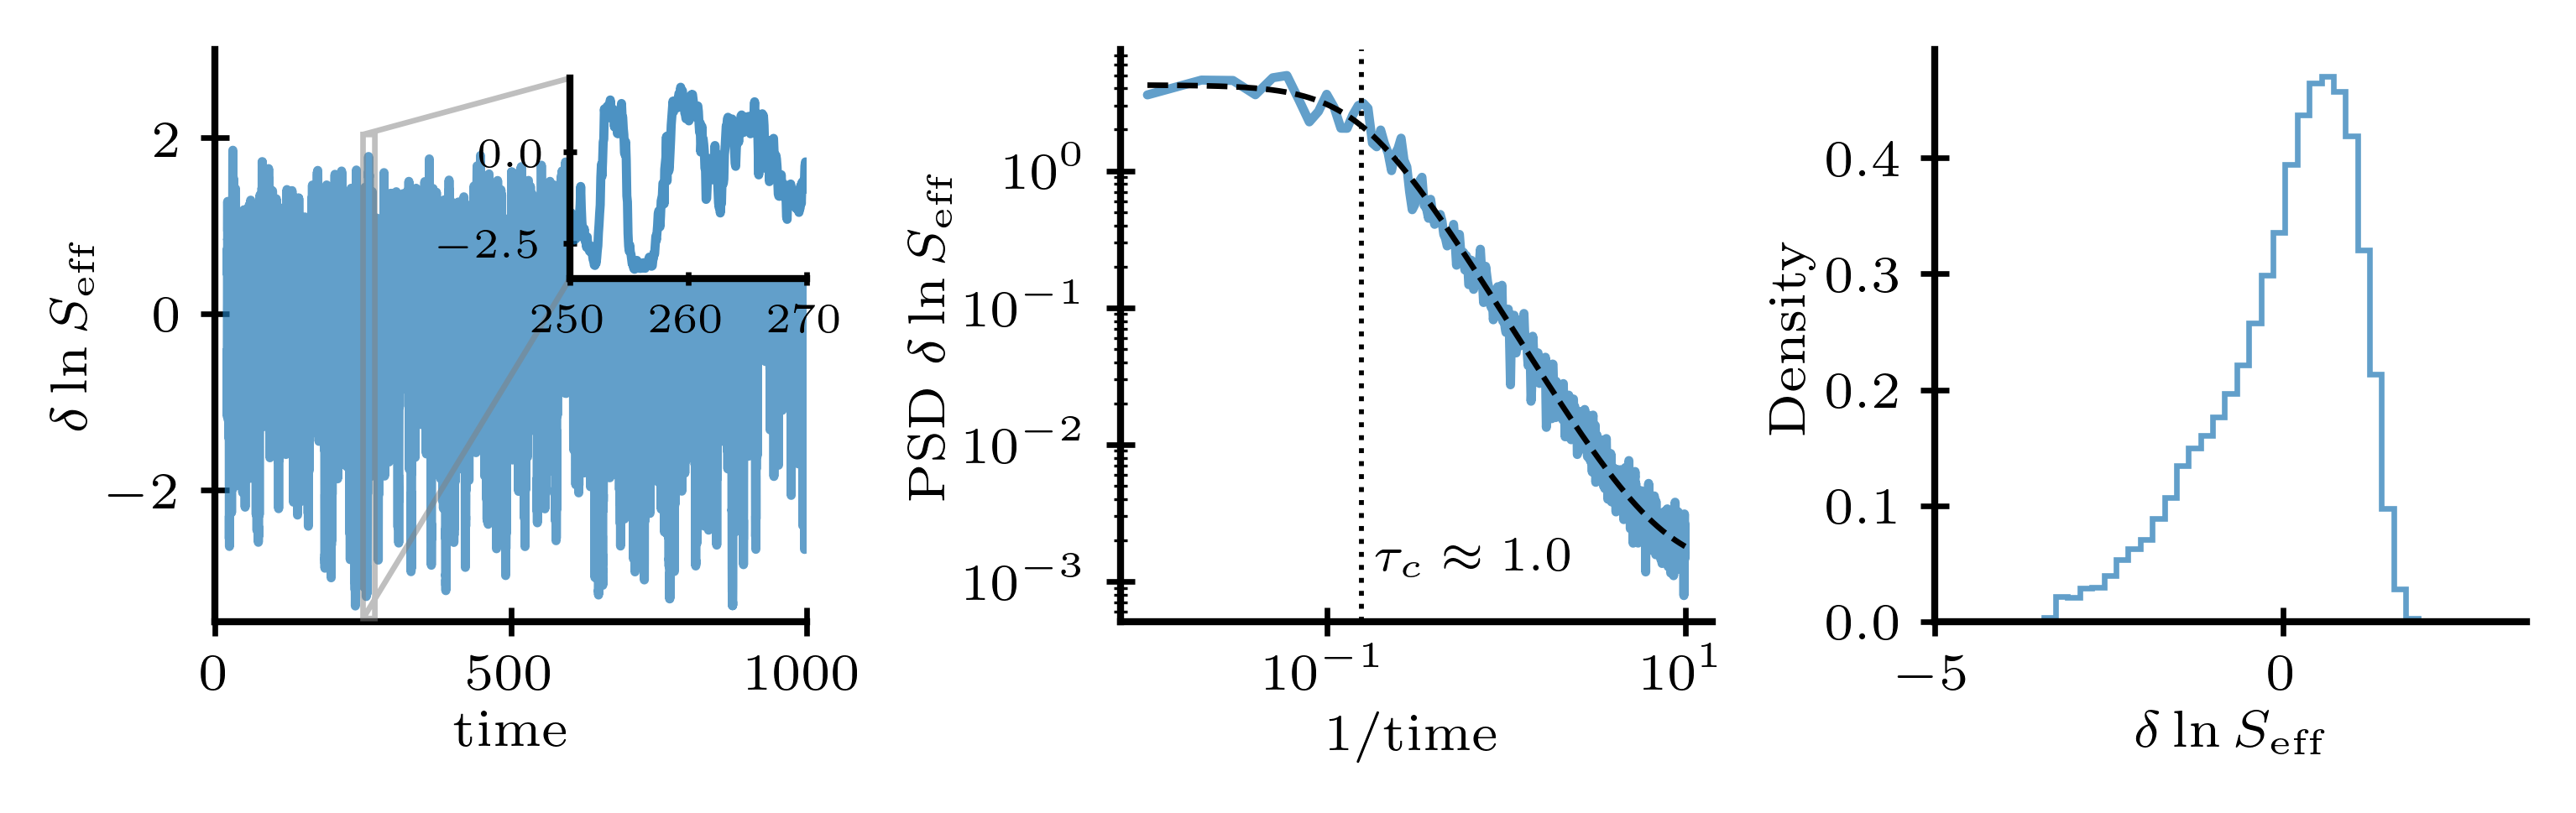

In [14]:
record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_{1.2}_theta_4.0.npz", allow_pickle=True)
t = record_long_term['t']
c_t = record_long_term['c']
Seff = np.zeros(len(t))
S = np.zeros(len(t))
for i, time in enumerate(t):
    Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
    S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
    
fig, ax = plt.subplots(1, 3, figsize=(5, 1.5), layout='constrained')

burn = int(len(t) * 0.02)
t = t[burn:]
logSeff =  np.log(Seff[burn:])
delta_logSeff = logSeff - np.mean(logSeff)

ax[0].plot(t, delta_logSeff, alpha=0.7)

dt = np.median(np.diff(t))
fs = 1 / dt

segment_time = 100
nperseg = int(segment_time / dt)
nperseg = min(nperseg, len(delta_logSeff))

f, Pxx = welch(delta_logSeff, fs=fs,  nperseg=nperseg, noverlap=nperseg // 2,  detrend="constant")
ax[1].loglog(f[1:], Pxx[1:], alpha=0.7)
ax[2].hist(delta_logSeff, density=True, histtype="step", bins=np.linspace(-5, 3.5, 50), alpha=0.7)
    
ax[0].set_xlim(0, 1000)
ax[0].set_ylim(-3.5, 3)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$\delta \ln S_{\mathrm{eff}}$')

t0, window = 250, 20
m = (t >= t0) & (t <= t0 + window)
axins = ax[0].inset_axes([0.6, 0.6, 0.4, 0.35])
axins.plot(t[m], delta_logSeff[m], alpha=0.8)
axins.set_xlim(t0, t0 + window)
ax[0].indicate_inset_zoom(axins)
axins.tick_params(labelsize=6, length=2)

ax[1].set_xlabel(r'1/time')
ax[1].set_ylabel(r'PSD $\delta \ln S_{\mathrm{eff}}$')

A, fc, beta, floor, tau = lib.fit_psd(f, Pxx)
f_fit = np.logspace(np.log10(f[1]), np.log10(f[-1]), 500)
P_fit = lib.psd_model(f_fit, A, fc, beta, floor)

ax[1].loglog(f_fit, P_fit, color="black", linestyle="--", lw=0.8)
ax[1].axvline(fc, color="black", linestyle=":", lw=0.7)
ax[1].text(0.43, 0.15, rf'$\tau_c \approx {tau:.1f}$', transform=ax[1].transAxes, fontsize=7, ha='left',va='top');

ax[2].set_xlim(-5, 3.5)
ax[2].set_xlabel(r'$\delta \ln S_{\mathrm{eff}}$')
ax[2].set_ylabel('Density')
plt.savefig('../../figures/how_to_maintain_diversity/long_time_fluctuations_with_source_1e4_alpha_1.2.svg', bbox_inches='tight', dpi=200, transparent=True);

### Varying $\theta / D$

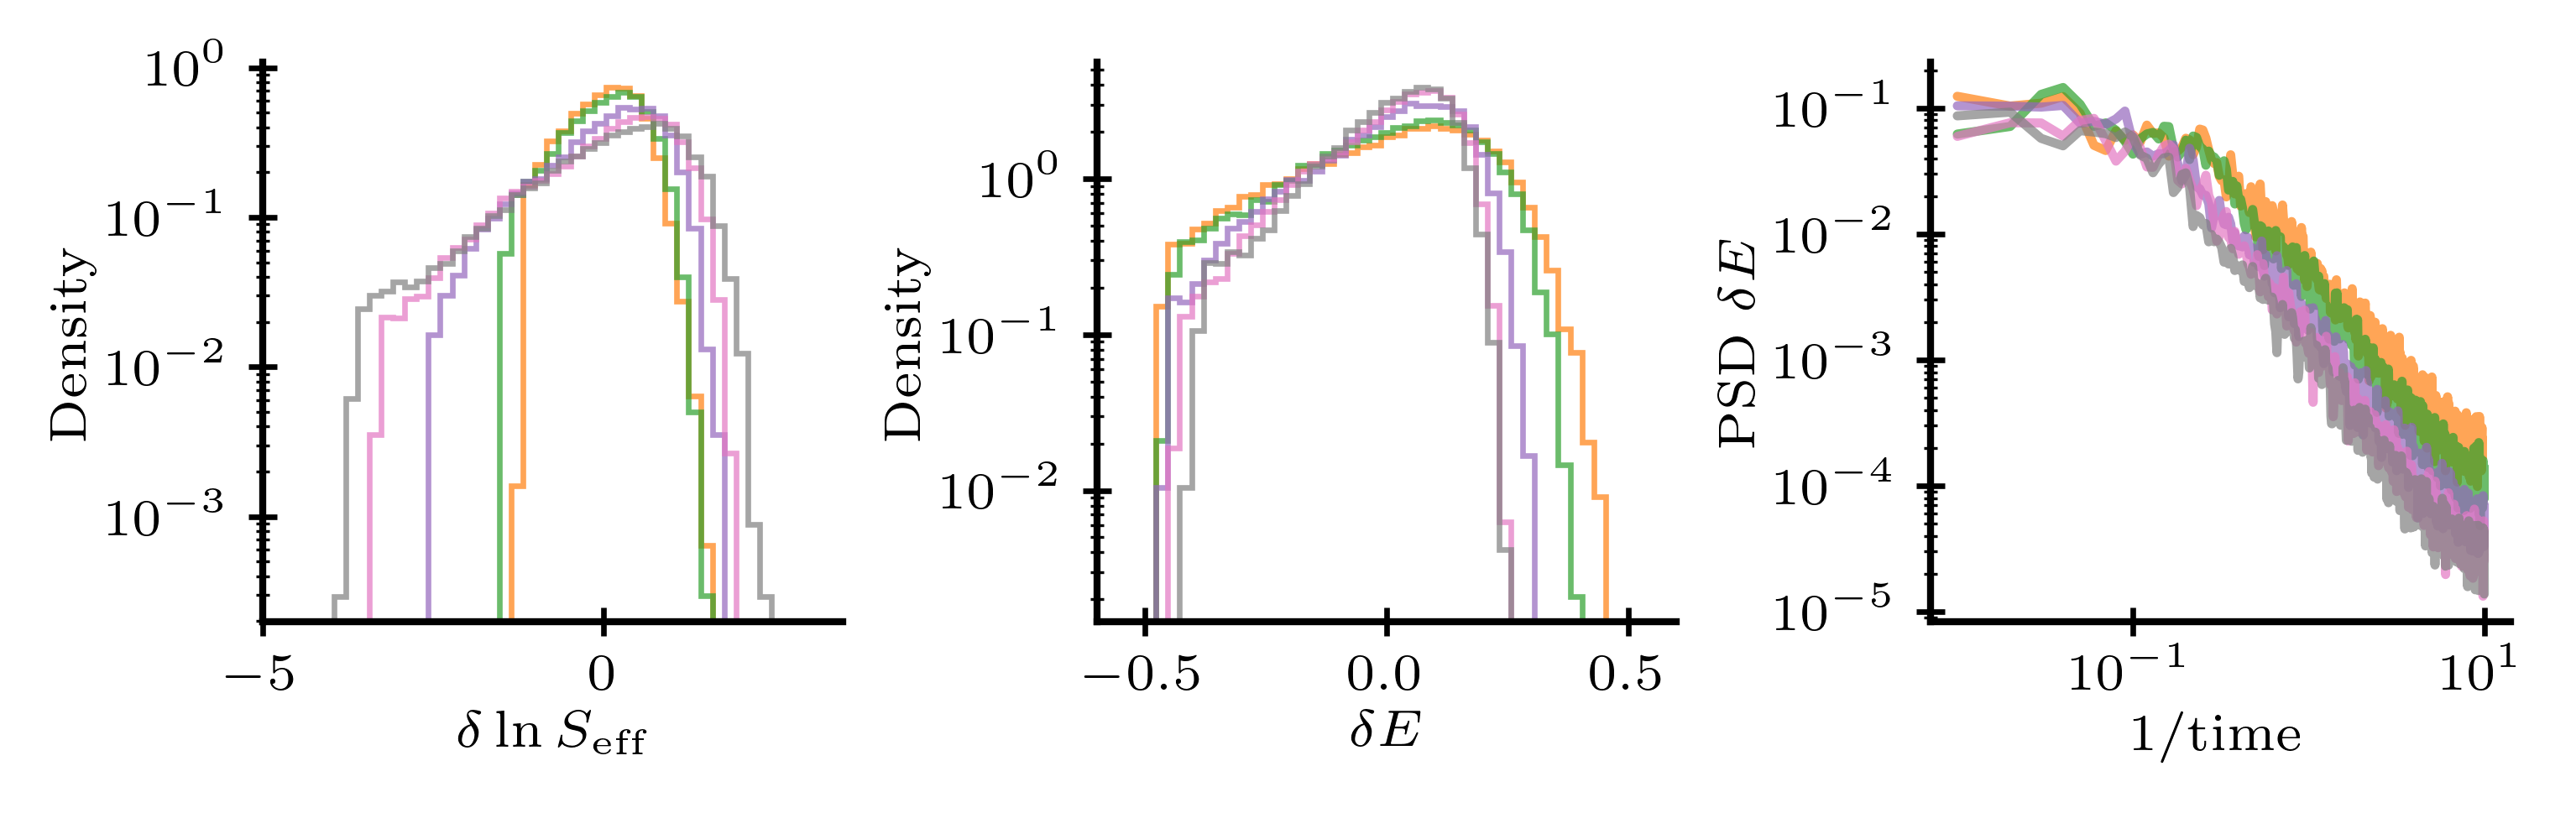

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(5, 1.5), layout='constrained')

ratios = [1.7, 2.0, 3.0, 4.0, 4.7]
colours = ['C1', 'C2', 'C4', 'C6', 'C7']
colours = {ratio:c for c, ratio in zip(colours, ratios)}
for ratio in ratios:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_1.2_theta_{ratio}.npz", allow_pickle=True)
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])  
        
    burn = int(len(t) * 0.02)
    t = t[burn:]
    logSeff =  np.log(Seff[burn:])
    delta_logSeff = logSeff - np.mean(logSeff)
    
    eveness = np.log(Seff[burn:]) / np.log(S[burn:])
    delta_eveness = eveness - np.mean(eveness)

    dt = np.median(np.diff(t))
    fs = 1 / dt

    segment_time = 100
    nperseg = int(segment_time / dt)
    nperseg = min(nperseg, len(delta_logSeff))

    f, Pxx = welch(delta_eveness, fs=fs,  nperseg=nperseg, noverlap=nperseg // 2,  detrend="constant")
    
    ax[0].hist(delta_logSeff, density=True, histtype="step", bins=np.linspace(-5, 3.5, 50), alpha=0.7, color=colours[ratio], label=rf"$\theta / D = {ratio:.1e}$")
    ax[1].hist(delta_eveness, density=True, histtype="step", bins=np.linspace(-0.6, 0.6, 50), alpha=0.7, color=colours[ratio])
    ax[2].loglog(f[1:], Pxx[1:], alpha=0.7, color=colours[ratio])
    
    ax[0].set_xlim(-5, 3.5)
    ax[0].set_xlabel(r'$\delta\ln S_{\mathrm{eff}}$')
    ax[0].set_ylabel('Density')
    ax[0].set_yscale('log')
    
    ax[1].set_xlim(-0.6, 0.6)
    ax[1].set_xlabel(r'$\delta E$')
    ax[1].set_ylabel('Density')
    ax[1].set_yscale('log')
    
    ax[2].set_xlabel(r'1/time')
    ax[2].set_ylabel(r'PSD $\delta E$')
plt.savefig('../../figures/how_to_maintain_diversity/long_time_fluctuations_with_source_alpha_1.2.svg', bbox_inches='tight', dpi=200, transparent=True);

## The impact of changing $\alpha$

### Scaling of $S_{\mathrm{eff}}$

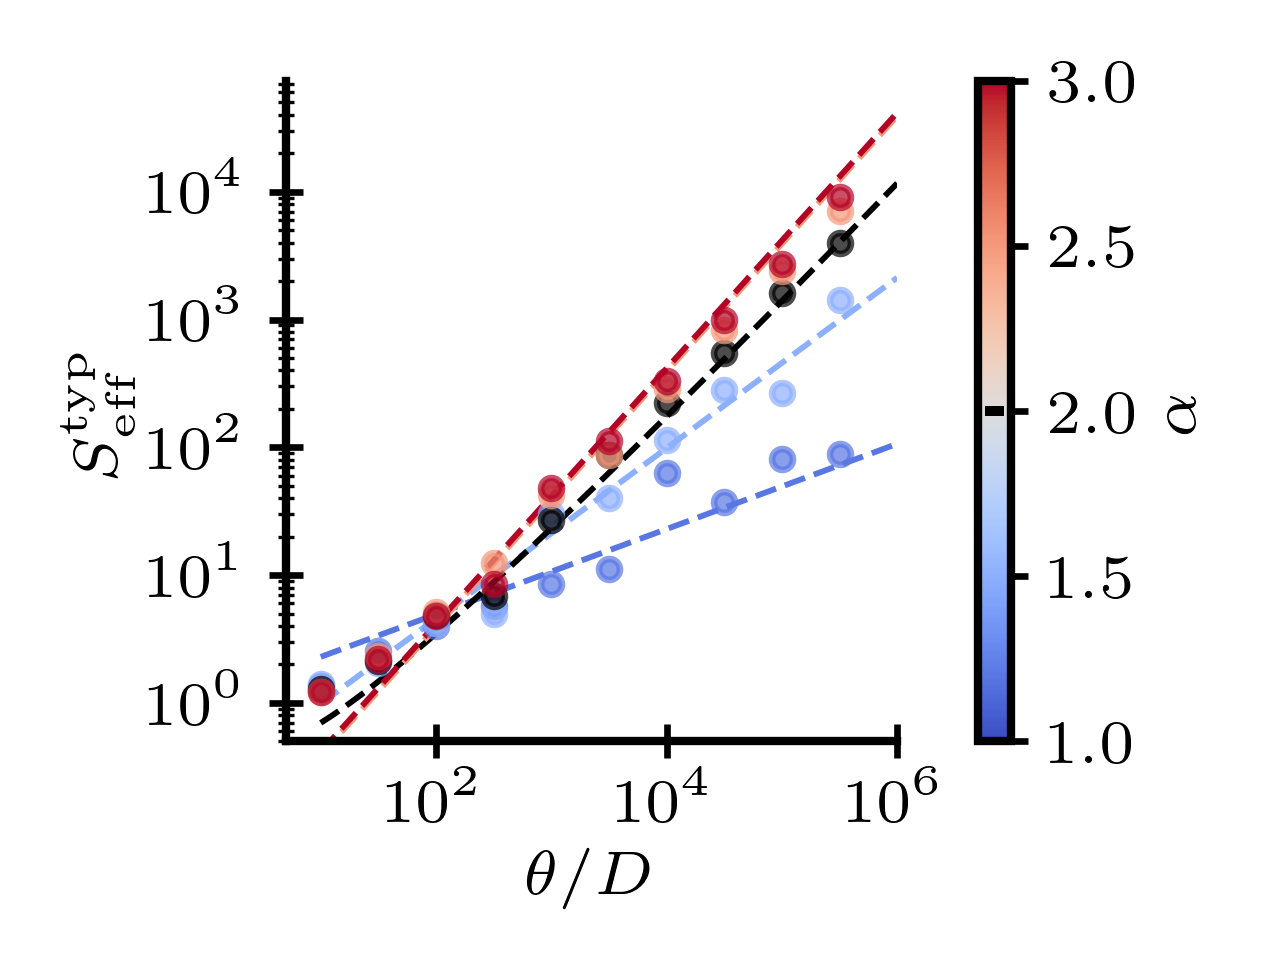

In [19]:
fig, ax = plt.subplots(figsize=(2, 1.5), layout='constrained')

ratios = np.logspace(1, 5.5, 10)
alphas = [1.2, 1.5, 2, 2.5, 3]

cmap = plt.get_cmap("coolwarm")
norm = TwoSlopeNorm(vmin=1, vcenter=2, vmax=3)
def alpha_colour(alpha):
    
    if np.isclose(alpha, 2):
        return "black"
    
    return cmap(norm(alpha))

for alpha in alphas:
    typical_diversities = []
    for ratio in ratios:
        
        records = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/alpha_{alpha}/ratio_{ratio}.npz", allow_pickle=True)
        t = records['t']
        c_t = records['c']
        
        Seff = np.zeros(len(t))
        for i, time in enumerate(t):
            Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        typical_diversities.append(lib.geometric_mean_after_burn(Seff))
        
    colour = alpha_colour(alpha)
        
    ax.scatter(ratios, typical_diversities, alpha=0.7, color=colour,)
    ratio_range = np.logspace(1, 6, 100)
    if alpha < 2:
        exponent = 2 * (alpha - 1) / alpha
        prefactor = lib.fit_power_law_prefactor(ratios, typical_diversities, exponent)
        ax.plot(ratio_range, prefactor*ratio_range**exponent, linestyle='--', lw=0.7, zorder=-2, color=colour)
    
    if alpha > 2:
        prefactor = lib.fit_power_law_prefactor(ratios, typical_diversities, 1)
        ax.plot(ratio_range, prefactor*ratio_range, linestyle='--', lw=0.7, zorder=-2, color=colour)
        
    if alpha == 2:
        z =  ratios / np.log(ratios)
        prefactor = np.sum(z * typical_diversities) / np.sum(z * z)
        ax.plot(ratio_range, prefactor*ratio_range / np.log(ratio_range), linestyle='--', lw=0.7, zorder=-2, color=colour)
        
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([5, 1e6])
ax.set_ylim([0.5, None]);
ax.set_xlabel(r'$\theta / D$')
ax.set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{typ}}$')

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, label=r"$\alpha$")
cbar.ax.plot([0.2, 0.8], [2, 2], color="black", lw=1.2, linestyle="--", transform=cbar.ax.get_yaxis_transform(), clip_on=False)
plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_diversity_with_recruitment.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Diversity fluctuations over long times

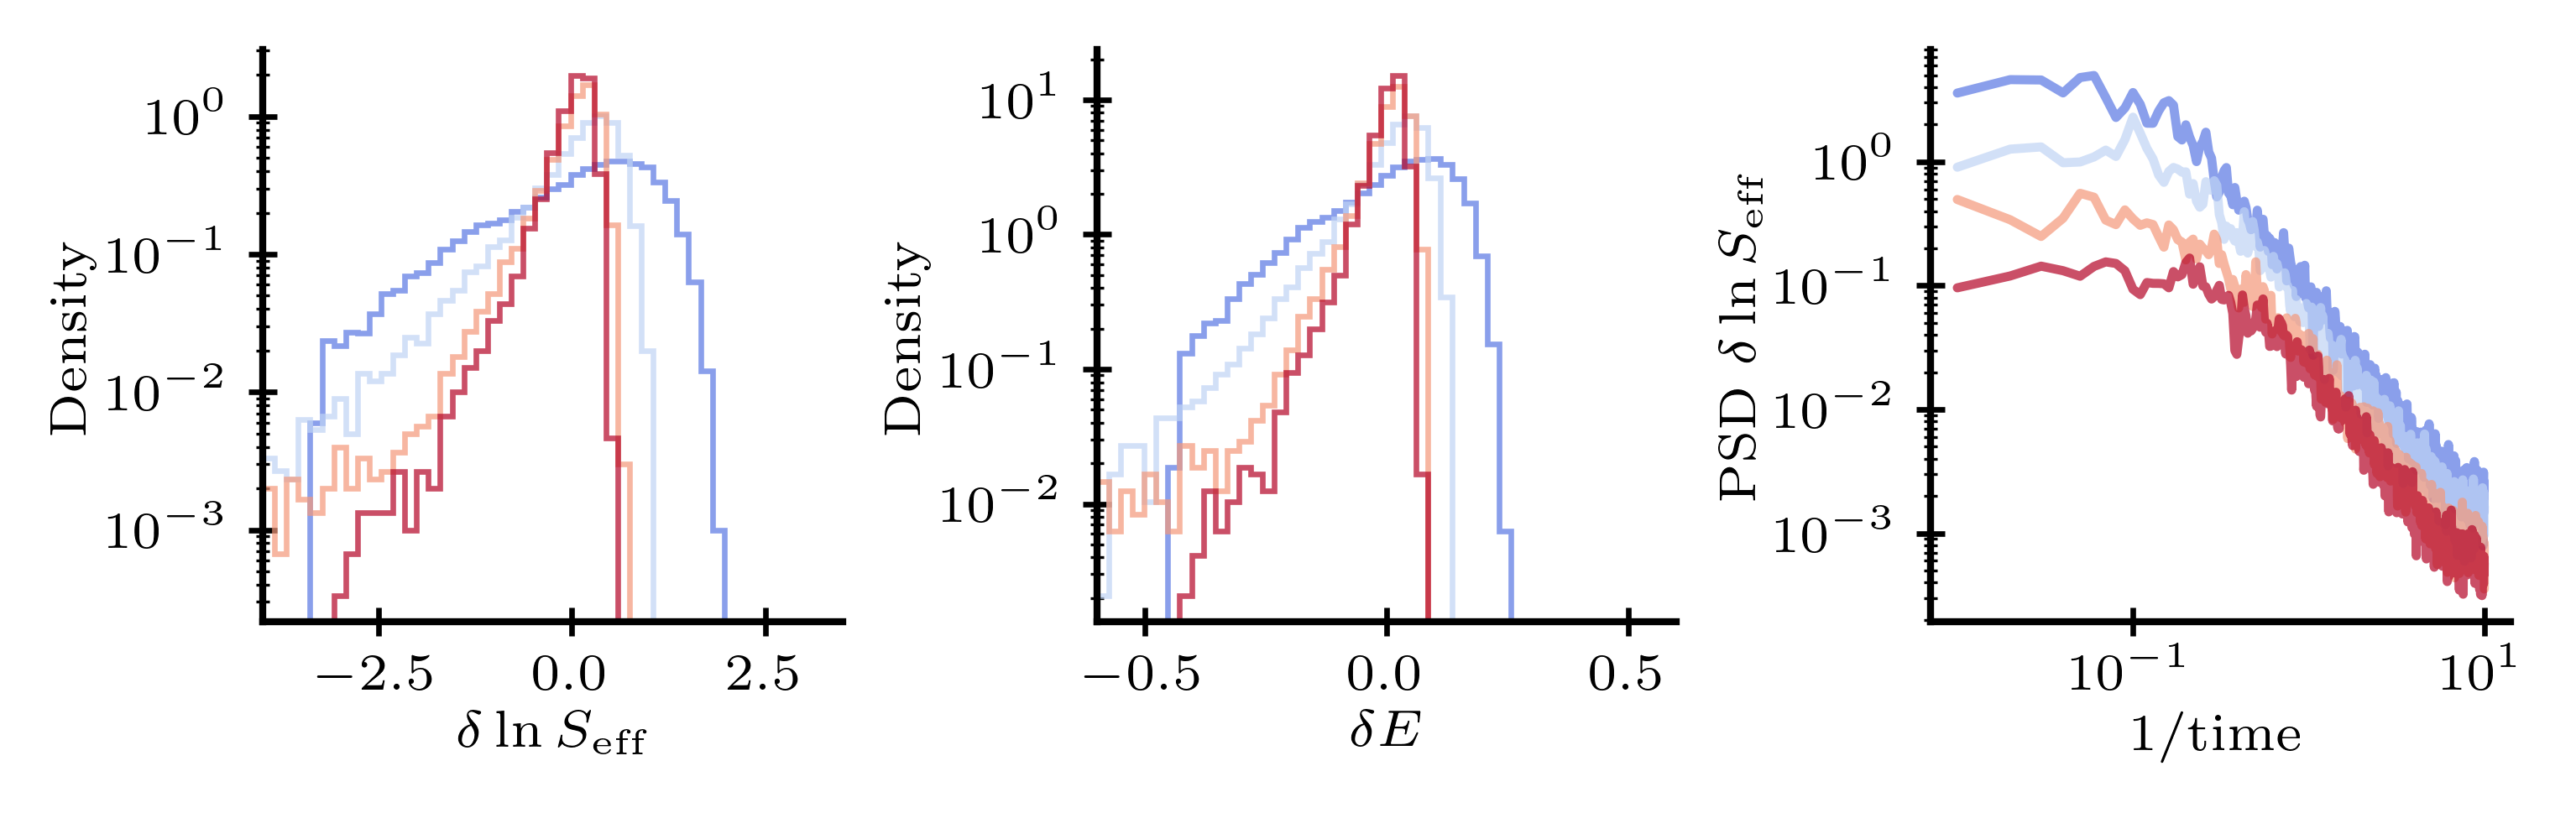

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(5, 1.5), layout='constrained')

alphas = [1.2, 1.8, 2.5, 3]
for alpha in alphas:
    colour = alpha_colour(alpha)
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_{alpha}_theta_4.0.npz", allow_pickle=True)
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))


    burn = int(len(t) * 0.02)
    t = t[burn:]
    logSeff =  np.log(Seff[burn:])
    delta_logSeff = logSeff - np.mean(logSeff)
    
    eveness = np.log(Seff[burn:]) / np.log(S[burn:])
    delta_eveness = eveness - np.mean(eveness)

    dt = np.median(np.diff(t))
    fs = 1 / dt

    segment_time = 100
    nperseg = int(segment_time / dt)
    nperseg = min(nperseg, len(delta_logSeff))

    f, Pxx = welch(delta_logSeff, fs=fs,  nperseg=nperseg, noverlap=nperseg // 2,  detrend="constant")
    ax[2].loglog(f[1:], Pxx[1:], c=colour, alpha=0.7)
    ax[0].hist(delta_logSeff, density=True, histtype="step", bins=np.linspace(-4, 3.5, 50), color=colour, alpha=0.7)
    
    ax[1].hist(delta_eveness, density=True, histtype="step", bins=np.linspace(-0.6, 0.6, 50), color=colour, alpha=0.7)
    ax[1].set_xlim(-0.6, 0.6)
    ax[1].set_xlabel(r'$\delta E$')
    ax[1].set_ylabel('Density')
    ax[1].set_yscale('log')
    
    ax[0].set_xlim(-4, 3.5)
    ax[0].set_xlabel(r'$\delta \ln S_{\mathrm{eff}}$')
    ax[0].set_ylabel('Density')
    ax[0].set_yscale('log')
    
    ax[2].set_xlabel(r'1/time')
    ax[2].set_ylabel(r'PSD $\delta \ln S_{\mathrm{eff}}$')
    plt.savefig('../../figures/how_to_maintain_diversity/long_time_fluctuations_with_alpha.pdf', bbox_inches='tight', dpi=200, transparent=True);

## TODO: use EVT to derive the shape of these fluctuation distributions and understand what sets the correlation timescale and the timescale of crashes